In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle as pk


import sys, os
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("../"), os.pardir)))
from customFunctions.utils import binary_auROC

from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, roc_curve, PrecisionRecallDisplay
from scipy import stats

In [2]:
mithril_features = pd.read_csv("../checkpoints/mithril_features.csv", sep="\t", index_col="Mithril_id")
mithril_features

,PhastCons_100V,PhyloP_100V,MLC_score,ss_distorsion,ddG,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,PWM_score,Human_MSA_position,bulge,stem,hairpin,loop,unpaired_frequency,closest_modification,closest_modification_2D,OEUF_score
Mithril_id,,,,,,,,,,,,,,,,,,,,
MITHRIL.1728,1.000,3.724,0.117871,0.028169,3.8,0.832225,0.143385,1.0,0.769628,14.0,-0.802033,0,0,1,0,0,0.011603,8,8.0,0.470
MITHRIL.1729,1.000,3.724,0.117871,0.028169,3.7,0.832225,0.004435,1.0,0.769628,14.0,-5.816984,0,0,1,0,0,0.011603,8,8.0,0.470
MITHRIL.1730,1.000,3.724,0.117871,0.028169,3.7,0.832225,0.019956,1.0,0.769628,14.0,-3.647059,0,0,1,0,0,0.011603,8,8.0,0.470
MITHRIL.1731,0.989,1.697,0.128976,0.028169,4.3,0.509978,0.005174,1.0,1.096296,10.0,-5.594591,1,0,1,0,0,0.014503,7,7.0,0.358
MITHRIL.1732,0.989,1.697,0.128976,0.028169,4.3,0.509978,0.477458,1.0,1.096296,10.0,0.933444,1,0,1,0,0,0.014503,7,7.0,0.358
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,1.000,3.604,0.738729,0.000000,0.7,0.956554,0.023564,1.0,0.316291,14.0,-3.407268,1,0,1,0,0,0.009386,7,5.0,0.358
MITHRIL.48240,1.000,3.604,0.738729,0.029412,4.7,0.956554,0.004418,1.0,0.316291,14.0,-5.822305,1,0,1,0,0,0.009386,7,5.0,0.358
MITHRIL.48241,1.000,5.938,0.734021,0.000000,1.9,0.981591,0.012518,1.0,0.154686,14.0,-4.319805,0,0,1,0,0,0.003610,8,6.0,0.470


In [3]:
embedding = pd.read_csv("../data/Mithril_msm_embedding.csv", index_col=0)
embedding.index.name = "Mithril_id"
embedding.columns = "channel_"+embedding.columns.astype(str)
embedding

,channel_0,channel_1,channel_2,channel_3,channel_4,channel_5,channel_6,channel_7,channel_8,channel_9,...,channel_758,channel_759,channel_760,channel_761,channel_762,channel_763,channel_764,channel_765,channel_766,channel_767
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1728,-0.046571,-0.464829,-1.071173,0.706031,0.254538,-0.839300,-0.785148,-0.686940,-0.066750,-0.083101,...,0.703984,-0.094465,0.001146,-0.474778,0.054920,0.746596,-0.846664,0.056164,0.580686,-0.568011
MITHRIL.1729,-0.094558,-0.843313,-0.774938,0.836958,-0.283595,-0.961378,-0.578084,-0.701949,0.039039,-0.158005,...,0.391420,-0.352180,0.091886,-0.714017,0.015839,0.481953,-0.791229,0.398780,0.376998,0.029397
MITHRIL.1730,0.050315,-0.794720,-0.958813,0.551639,-0.071321,-0.767290,-0.558026,-0.843187,0.249865,-0.380568,...,0.306507,-0.153325,0.306693,-0.223419,-0.042577,0.929070,-0.781954,0.641456,0.126171,0.083980
MITHRIL.1731,-0.271729,-0.401465,-0.722368,0.715860,-0.171587,-0.678559,-0.540892,-0.339579,-0.256668,-0.268223,...,0.985569,0.165077,-0.349262,-0.658368,-0.430892,-0.193119,-0.840392,-0.930292,0.894584,-0.970570
MITHRIL.1732,-0.189935,-0.290123,-0.115013,0.859563,-0.127386,-0.715655,-0.411798,-0.926073,-0.151554,-0.170612,...,1.006938,-0.278918,-0.724813,-0.523815,-0.416955,0.000319,-1.031683,-0.880209,1.119973,-0.960705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,0.085203,0.720789,0.258117,-0.241561,0.276256,0.001175,0.117050,-0.357717,0.238088,0.165467,...,-0.069218,0.467677,-0.082058,0.037380,0.941805,-0.044995,-0.369644,0.526498,-0.601754,-0.447180
MITHRIL.48240,-0.516000,0.442102,0.331330,0.229251,-0.081880,-0.531516,0.226194,-0.564276,0.209845,-0.133919,...,-0.124533,0.285401,-0.201929,-0.403190,0.809152,0.175132,-0.162785,0.336191,-0.763395,-0.056434
MITHRIL.48241,0.318094,0.357954,-0.837745,-0.545639,-0.157910,0.394076,-1.226594,-0.005673,0.406269,-0.306028,...,-0.098943,0.436399,0.025024,1.110456,-0.265077,0.567142,-0.822745,-0.657988,-0.763098,-0.291456


In [4]:
X = mithril_features.join(embedding)
X.shape

(4521, 788)

In [5]:
y_test = pd.read_csv("../data/test_set.txt", sep="\t", index_col="Mithril_id").label\
    .replace(["Pathogenic", "Likely pathogenic", "Benign", "Likely benign"], [1,1,0,0])
X_test = X.loc[y_test.index]
X_test

/tmp/ipykernel_1098798/710766961.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(["Pathogenic", "Likely pathogenic", "Benign", "Likely benign"], [1,1,0,0])


,PhastCons_100V,PhyloP_100V,MLC_score,ss_distorsion,ddG,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,...,channel_758,channel_759,channel_760,channel_761,channel_762,channel_763,channel_764,channel_765,channel_766,channel_767
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1846,1.000,3.707,0.510351,0.028169,1.1,0.942350,0.022173,1.000000,0.408534,14.0,...,0.670284,-0.187625,-0.493014,-0.333382,0.179401,0.408108,-0.683268,-0.737266,0.498617,-1.002428
MITHRIL.4929,0.996,0.980,0.327147,0.000000,0.0,0.817638,0.115845,0.991111,0.922203,5.0,...,0.379588,0.354751,0.390387,-0.997868,-0.110256,0.919109,-0.859502,0.172431,0.486186,-0.654698
MITHRIL.9729,1.000,5.826,0.850926,0.000000,-0.3,0.992614,0.000000,1.000000,0.066377,10.0,...,-0.425040,0.140006,-0.648723,-0.194253,0.805011,0.380403,-0.498180,0.813303,-1.425700,0.438128
MITHRIL.9728,1.000,5.826,0.850926,0.000000,-1.2,0.992614,0.006647,1.000000,0.066377,10.0,...,-0.178584,0.298345,-0.759088,0.083235,1.046968,0.318218,-0.465996,0.723391,-1.183443,0.407064
MITHRIL.9752,0.456,0.908,0.797513,0.000000,0.0,0.739008,0.035547,0.789513,1.215301,9.0,...,-0.057042,0.741527,-0.704968,-0.290943,0.564526,-0.091588,-0.721032,0.827592,-0.592988,0.011270
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.17470,0.000,-0.238,0.312028,0.000000,2.2,0.262963,0.689630,1.000000,1.128278,0.0,...,0.171333,0.873823,-0.128143,0.210718,-0.723211,1.073902,-0.699213,-0.288812,-0.098388,-0.583400
MITHRIL.17540,0.000,0.876,0.656165,0.000000,0.0,0.859806,0.014914,0.993333,0.753068,2.0,...,0.339020,0.419849,-0.422917,-0.410678,-0.192811,0.509847,-0.800014,-0.705664,1.058065,-0.595274
MITHRIL.30284,0.000,-0.125,0.338614,0.000000,0.0,0.858940,0.024259,0.824444,0.884878,3.0,...,-0.495467,0.495154,0.294965,-0.449407,0.286263,-0.445074,-0.055157,-0.037730,-0.095185,-0.331934


In [6]:
tuned_model = pk.load(open("../checkpoints/candidate_models/model_svc.pk", "rb"))
tuned_model

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('input_selection',
                                        ColumnTransformerDF(transformers=[('feature_selection',
                                                                           SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                                              random_state=777),
                                                                                             threshold=0.01),
                                                                           Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'ss_distorsion', '...
                                                                       scoring_function=<function roc_auc_score at 0x70d83842dc60>))]),
             n_jobs=1,
             param_grid={'channels_correlation_filter__corr_threshold': [0.2,
                                                                         0.25,
                                                                         0.3,
                                                                         0.4],
                         'channels_pca__n_components': [1, 2, 3, 5],
                         'input_selection__channel_selection__alpha': [0.01,
                                                                       0.05,
                                                                       0.1],
                         'input_selection__feature_selection__threshold': [0.01,
                                                                           0.02,
                                                                           0.03,
                                                                           0.04,
                                                                           0.05]},
             scoring=<function binary_auROC at 0x70d838700400>, verbose=2)

In [41]:
X_masked = X.copy()
X_masked.loc[:, X_masked.columns.str.match("channel_")] = X_masked.loc[:, X_masked.columns.str.match("channel_")].mean().values
X_masked

,PhastCons_100V,PhyloP_100V,MLC_score,ss_distorsion,ddG,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,...,channel_758,channel_759,channel_760,channel_761,channel_762,channel_763,channel_764,channel_765,channel_766,channel_767
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1728,1.000,3.724,0.117871,0.028169,3.8,0.832225,0.143385,1.0,0.769628,14.0,...,0.21023,0.266651,-0.053556,-0.29928,0.09132,0.276962,-0.545487,-0.087955,-0.112693,-0.443952
MITHRIL.1729,1.000,3.724,0.117871,0.028169,3.7,0.832225,0.004435,1.0,0.769628,14.0,...,0.21023,0.266651,-0.053556,-0.29928,0.09132,0.276962,-0.545487,-0.087955,-0.112693,-0.443952
MITHRIL.1730,1.000,3.724,0.117871,0.028169,3.7,0.832225,0.019956,1.0,0.769628,14.0,...,0.21023,0.266651,-0.053556,-0.29928,0.09132,0.276962,-0.545487,-0.087955,-0.112693,-0.443952
MITHRIL.1731,0.989,1.697,0.128976,0.028169,4.3,0.509978,0.005174,1.0,1.096296,10.0,...,0.21023,0.266651,-0.053556,-0.29928,0.09132,0.276962,-0.545487,-0.087955,-0.112693,-0.443952
MITHRIL.1732,0.989,1.697,0.128976,0.028169,4.3,0.509978,0.477458,1.0,1.096296,10.0,...,0.21023,0.266651,-0.053556,-0.29928,0.09132,0.276962,-0.545487,-0.087955,-0.112693,-0.443952
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,1.000,3.604,0.738729,0.000000,0.7,0.956554,0.023564,1.0,0.316291,14.0,...,0.21023,0.266651,-0.053556,-0.29928,0.09132,0.276962,-0.545487,-0.087955,-0.112693,-0.443952
MITHRIL.48240,1.000,3.604,0.738729,0.029412,4.7,0.956554,0.004418,1.0,0.316291,14.0,...,0.21023,0.266651,-0.053556,-0.29928,0.09132,0.276962,-0.545487,-0.087955,-0.112693,-0.443952
MITHRIL.48241,1.000,5.938,0.734021,0.000000,1.9,0.981591,0.012518,1.0,0.154686,14.0,...,0.21023,0.266651,-0.053556,-0.29928,0.09132,0.276962,-0.545487,-0.087955,-0.112693,-0.443952


In [42]:
y_pred_ablation = tuned_model.predict_proba(X_masked.loc[y_test.index])[:,1]
y_pred_ablation

array([0.76840527, 0.46306199, 0.71377688, 0.76823303, 0.63732092,
       0.86050791, 0.76513572, 0.69147918, 0.77593924, 0.75706159,
       0.64727592, 0.5579526 , 0.55848723, 0.64705425, 0.83896571,
       0.79829991, 0.62715915, 0.54706675, 0.85037317, 0.63878256,
       0.64374547, 0.29349583, 0.63317292, 0.65486164, 0.80038656,
       0.56367854, 0.24216194, 0.60528833, 0.72850611, 0.71647815,
       0.48831678, 0.65051947, 0.78305438, 0.79937632, 0.23014623,
       0.66500076, 0.6381957 , 0.7183996 , 0.43988056, 0.28356219,
       0.17970945, 0.2646143 , 0.26219323, 0.33818419, 0.26333307,
       0.33317618, 0.14787148, 0.37367139, 0.22079129, 0.31525491,
       0.36590495, 0.17339691, 0.25874768, 0.43261301, 0.11998229,
       0.35957803, 0.20680353, 0.39251258, 0.17397476, 0.46059352,
       0.1470379 , 0.23498532, 0.31672912, 0.16469758, 0.33885225,
       0.38448257, 0.29295477, 0.41220968, 0.31260233, 0.44647149,
       0.50958564])

In [43]:
roc_auc_score(y_test, y_pred_ablation)

np.float64(0.9473684210526315)

In [11]:
roc_auc_score(y_test, tuned_model.predict_proba(X_test)[:,1])

np.float64(0.9338118022328549)

In [44]:
X_test_preprocessed = tuned_model.best_estimator_[:-1].transform(X_test)
X_test_preprocessed.index = X_test.index
X_test_preprocessed

,PhastCons_100V,PhyloP_100V,MLC_score,ss_distorsion,ddG,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,PWM_score,Human_MSA_position,unpaired_frequency,closest_modification,OEUF_score,PC_1,PC_2,PC_3,PC_4,PC_5
Mithril_id,,,,,,,,,,,,,,,,,,,,
MITHRIL.1846,1.176727,0.711158,0.413688,1.545045,0.142493,1.321822,-0.853513,0.342769,-1.448622,1.598726,-0.177702,0.049443,-1.029618,-1.039725,-0.638670,-1.873924,3.182626,-0.973459,-0.746695,-1.189497
MITHRIL.4929,1.168308,0.054285,-0.457583,-0.561018,-0.402560,0.905433,-0.425025,0.247079,-0.356110,-0.318998,0.169980,0.315384,1.066218,-0.229119,0.776041,6.530205,1.982008,2.000665,0.226490,0.712342
MITHRIL.9729,1.176727,1.221578,2.033383,-0.561018,-0.551211,1.489644,-0.954940,0.342769,-2.176350,0.746405,-6.155576,-1.191618,1.066218,-0.499321,-0.164618,1.889224,-3.155263,1.072325,-2.481602,-1.253909
MITHRIL.9728,1.176727,1.221578,2.033383,-0.561018,-0.997164,1.489644,-0.924534,0.342769,-2.176350,0.746405,-0.431037,-1.191618,1.066218,-0.499321,-0.164618,0.689623,-2.649321,0.993080,-0.872416,-0.095071
MITHRIL.9752,0.031636,0.036942,1.779364,-0.561018,-0.402560,0.642904,-0.792334,-1.923165,0.267275,0.533324,-0.078450,-0.837029,1.066218,-0.904624,-0.450042,-2.253925,-3.315884,0.482616,-1.315866,1.111590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.17470,-0.928220,-0.239104,-0.529483,-0.561018,0.687547,-0.946516,2.199677,0.342769,0.082187,-1.384400,0.545111,-1.546206,-1.004472,-0.634422,-0.360692,5.610910,-0.893372,-3.410887,-2.683989,-0.075463
MITHRIL.17540,-0.928220,0.029234,1.107146,-0.561018,-0.402560,1.046223,-0.886717,0.271001,-0.715841,-0.958239,-0.260936,0.714297,1.066218,-0.229119,1.024236,-3.271276,5.330246,1.692149,-2.265298,-0.598501
MITHRIL.30284,-0.928220,-0.211885,-0.403048,-0.561018,-0.402560,1.043331,-0.843971,-1.547117,-0.435497,-0.745158,-0.158797,0.891591,1.066218,1.256993,0.105915,-3.706882,-3.163123,0.652967,2.081510,-1.636489


In [46]:
X_test_masked_preprocessed = tuned_model.best_estimator_[:-1].transform(X_masked.loc[X_test.index])
X_test_masked_preprocessed.index = X_test.index
X_test_masked_preprocessed

,PhastCons_100V,PhyloP_100V,MLC_score,ss_distorsion,ddG,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,PWM_score,Human_MSA_position,unpaired_frequency,closest_modification,OEUF_score,PC_1,PC_2,PC_3,PC_4,PC_5
Mithril_id,,,,,,,,,,,,,,,,,,,,
MITHRIL.1846,1.176727,0.711158,0.413688,1.545045,0.142493,1.321822,-0.853513,0.342769,-1.448622,1.598726,-0.177702,0.049443,-1.029618,-1.039725,-0.638670,0.758545,0.249192,0.292477,-0.030559,-0.037412
MITHRIL.4929,1.168308,0.054285,-0.457583,-0.561018,-0.402560,0.905433,-0.425025,0.247079,-0.356110,-0.318998,0.169980,0.315384,1.066218,-0.229119,0.776041,0.758545,0.249192,0.292477,-0.030559,-0.037412
MITHRIL.9729,1.176727,1.221578,2.033383,-0.561018,-0.551211,1.489644,-0.954940,0.342769,-2.176350,0.746405,-6.155576,-1.191618,1.066218,-0.499321,-0.164618,0.758545,0.249192,0.292477,-0.030559,-0.037412
MITHRIL.9728,1.176727,1.221578,2.033383,-0.561018,-0.997164,1.489644,-0.924534,0.342769,-2.176350,0.746405,-0.431037,-1.191618,1.066218,-0.499321,-0.164618,0.758545,0.249192,0.292477,-0.030559,-0.037412
MITHRIL.9752,0.031636,0.036942,1.779364,-0.561018,-0.402560,0.642904,-0.792334,-1.923165,0.267275,0.533324,-0.078450,-0.837029,1.066218,-0.904624,-0.450042,0.758545,0.249192,0.292477,-0.030559,-0.037412
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.17470,-0.928220,-0.239104,-0.529483,-0.561018,0.687547,-0.946516,2.199677,0.342769,0.082187,-1.384400,0.545111,-1.546206,-1.004472,-0.634422,-0.360692,0.758545,0.249192,0.292477,-0.030559,-0.037412
MITHRIL.17540,-0.928220,0.029234,1.107146,-0.561018,-0.402560,1.046223,-0.886717,0.271001,-0.715841,-0.958239,-0.260936,0.714297,1.066218,-0.229119,1.024236,0.758545,0.249192,0.292477,-0.030559,-0.037412
MITHRIL.30284,-0.928220,-0.211885,-0.403048,-0.561018,-0.402560,1.043331,-0.843971,-1.547117,-0.435497,-0.745158,-0.158797,0.891591,1.066218,1.256993,0.105915,0.758545,0.249192,0.292477,-0.030559,-0.037412


In [49]:
roc_auc_score(y_test, tuned_model.best_estimator_[-1].predict_proba(X_test_preprocessed)[:,1])

np.float64(0.9338118022328549)

In [50]:
roc_auc_score(y_test, tuned_model.best_estimator_[-1].predict_proba(X_test_masked_preprocessed)[:,1])

np.float64(0.9473684210526315)

In [68]:
import tqdm
ablation_auc = {}
for i in tqdm.tqdm(range(250)):
    ablation_auc[i] = {}
    for feature in X_test_preprocessed.columns:
        X_masked = X_test_preprocessed.copy()
        X_masked[feature] = np.random.permutation(X_masked[feature])
        # X_masked[feature] = X_masked[feature].mean()
        y_pred_ablation = tuned_model.best_estimator_[-1].predict_proba(X_masked.loc[y_test.index])[:,1]
        ablation_auc[i][feature] = roc_auc_score(y_test, y_pred_ablation)
        # print(f"no {feature} AUROC: {ablation_auc[i][feature]}")
ablation_auc = pd.DataFrame(ablation_auc)
ablation_auc

100%|██████████| 250/250 [09:56<00:00,  2.39s/it]


,0,1,2,3,4,5,6,7,8,9,...,240,241,242,243,244,245,246,247,248,249
PhastCons_100V,0.939394,0.933014,0.933014,0.929027,0.917065,0.930622,0.913078,0.925040,0.922648,0.921850,...,0.917863,0.905901,0.918660,0.918660,0.920255,0.905901,0.933812,0.934609,0.929027,0.930622
PhyloP_100V,0.929825,0.931419,0.933014,0.938596,0.937002,0.929027,0.932217,0.938596,0.936204,0.932217,...,0.933812,0.929825,0.945774,0.933014,0.931419,0.937799,0.932217,0.936204,0.944179,0.933014
MLC_score,0.900319,0.930622,0.909888,0.901914,0.896332,0.933812,0.916268,0.912281,0.891547,0.897927,...,0.916268,0.908293,0.924242,0.893142,0.911483,0.934609,0.886762,0.914673,0.906699,0.928230
ss_distorsion,0.927432,0.930622,0.932217,0.944179,0.936204,0.937002,0.941786,0.941786,0.939394,0.945774,...,0.937002,0.938596,0.937002,0.937002,0.940989,0.931419,0.940191,0.941786,0.942584,0.943381
ddG,0.954545,0.920255,0.944179,0.931419,0.945774,0.933014,0.929027,0.959330,0.948166,0.926635,...,0.944976,0.937799,0.934609,0.942584,0.951356,0.947368,0.931419,0.937799,0.950558,0.942584
ref_frequency,0.943381,0.933812,0.941786,0.940191,0.938596,0.938596,0.944976,0.937002,0.934609,0.937799,...,0.936204,0.934609,0.939394,0.940989,0.937799,0.937002,0.939394,0.935407,0.937002,0.939394
alt_frequency,0.934609,0.938596,0.936204,0.935407,0.933812,0.935407,0.933812,0.939394,0.933812,0.942584,...,0.936204,0.933014,0.937799,0.935407,0.936204,0.937799,0.936204,0.937799,0.939394,0.933812
coverage,0.936204,0.933812,0.937002,0.935407,0.937002,0.936204,0.936204,0.936204,0.935407,0.936204,...,0.936204,0.936204,0.937002,0.935407,0.934609,0.933014,0.936204,0.938596,0.933812,0.934609
entropy,0.943381,0.940191,0.925837,0.925837,0.935407,0.940191,0.928230,0.937002,0.933812,0.935407,...,0.934609,0.931419,0.933812,0.934609,0.935407,0.933812,0.923445,0.940191,0.935407,0.937799
conservation_blocks,0.925837,0.929027,0.916268,0.939394,0.938596,0.925837,0.932217,0.932217,0.929027,0.932217,...,0.914673,0.919458,0.946571,0.920255,0.924242,0.928230,0.912281,0.917065,0.922648,0.933812


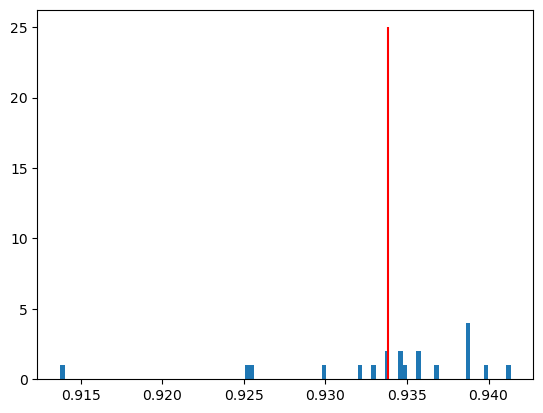

In [70]:
plt.hist(ablation_auc.mean(axis=1), bins=100)
plt.vlines(roc_auc_score(y_test, tuned_model.predict_proba(X_test)[:,1]), 0, 25, colors="red")

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'PhastCons_100V'),
  Text(1, 0, 'PhyloP_100V'),
  Text(2, 0, 'MLC_score'),
  Text(3, 0, 'ss_distorsion'),
  Text(4, 0, 'ddG'),
  Text(5, 0, 'ref_frequency'),
  Text(6, 0, 'alt_frequency'),
  Text(7, 0, 'coverage'),
  Text(8, 0, 'entropy'),
  Text(9, 0, 'conservation_blocks'),
  Text(10, 0, 'PWM_score'),
  Text(11, 0, 'Human_MSA_position'),
  Text(12, 0, 'unpaired_frequency'),
  Text(13, 0, 'closest_modification'),
  Text(14, 0, 'OEUF_score'),
  Text(15, 0, 'PC_1'),
  Text(16, 0, 'PC_2'),
  Text(17, 0, 'PC_3'),
  Text(18, 0, 'PC_4'),
  Text(19, 0, 'PC_5')])

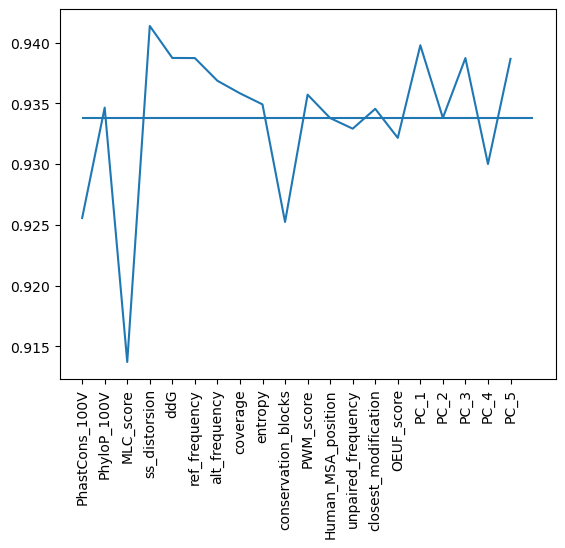

In [71]:
plt.plot(ablation_auc.mean(axis=1))
plt.hlines(roc_auc_score(y_test, tuned_model.predict_proba(X_test)[:,1]), 0, 20)
plt.xticks(None, rotation=90)

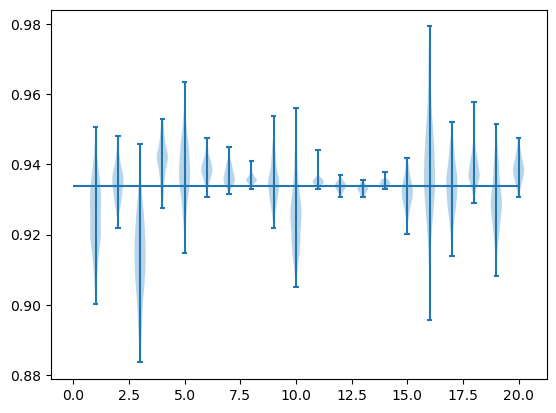

In [75]:
plt.violinplot(ablation_auc.T)
plt.hlines(roc_auc_score(y_test, tuned_model.predict_proba(X_test)[:,1]), 0, 20)
plt.show()

In [80]:
(ablation_auc.T>roc_auc_score(y_test, tuned_model.predict_proba(X_test)[:,1])).mean()

PhastCons_100V          0.196
PhyloP_100V             0.556
MLC_score               0.044
ss_distorsion           0.892
ddG                     0.708
ref_frequency           0.944
alt_frequency           0.860
coverage                0.920
entropy                 0.540
conservation_blocks     0.156
PWM_score               0.892
Human_MSA_position      0.384
unpaired_frequency      0.136
closest_modification    0.620
OEUF_score              0.300
PC_1                    0.636
PC_2                    0.480
PC_3                    0.868
PC_4                    0.284
PC_5                    0.900
dtype: float64

In [82]:
tuned_model.best_estimator_

Pipeline(steps=[('input_selection',
                 ColumnTransformerDF(transformers=[('feature_selection',
                                                    SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                       random_state=777),
                                                                      threshold=0.01),
                                                    Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'ss_distorsion', 'ddG',
       'ref_frequency', 'alt_frequency', 'coverage', 'entropy',
       'conservation_blocks', 'PWM...
                 GridSearchOOB_BinaryClassifier(estimator=BalancedBaggingClassifier(estimator=SVC(C=10,
                                                                                                  gamma=0.01,
                                                                                                  probability=True),
                                                                                    max_features=0.5,
                                                                                    n_estimators=500,
                                                                                    n_jobs=-1,
                                                                                    oob_score=True,
                                                                                    replacement=True,
                                                                                    sampling_strategy='not '
                                                                                                      'minority'),
                                                n_jobs=-1,
                                                param_grid=<sklearn.model_selection._search.ParameterGrid object at 0x70d8368d2fd0>,
                                                scoring_function=<function roc_auc_score at 0x70d83842dc60>))])

In [83]:
tuned_model.cv

StratifiedKFold(n_splits=10, random_state=42, shuffle=True)